# 1. Face Dataset Splitter (Train: 70%, Val: 20%, Test: 10%)
This cell preserves class balance, copies images into their respective split folders, and prints the summary using `sklearn` and `shutil`.

In [9]:
import os
from pathlib import Path
from collections import defaultdict
import random, math, pickle

ROOT = Path(".")
LFW_DATASET_ROOT = ROOT / "lfw_dataset"
_candidates = [
    LFW_DATASET_ROOT / "lfw",
    LFW_DATASET_ROOT / "lfw-deepfunneled" / "lfw-deepfunneled",
    LFW_DATASET_ROOT / "lfw-deepfunneled",
]
CACHE_FILE = LFW_DATASET_ROOT / "rtdetr_vit_embeddings_cache.pkl"
LFW_DIR = next((p for p in _candidates if p.exists()), LFW_DATASET_ROOT / "lfw")

MIN_IMAGES = 5
RANDOM_SEED = 42
TRAIN_RATIO = 0.70
VAL_RATIO = 0.10
TEST_RATIO = 0.20

def collect_persons(min_images: int):
    persons = defaultdict(list)
    for d in sorted(LFW_DIR.iterdir()):
        if not d.is_dir(): continue
        imgs = sorted(d.glob("*.jpg"))
        if len(imgs) >= min_images:
            persons[d.name] = [str(p) for p in imgs]
    total = sum(len(v) for v in persons.values())
    print(f"Found {len(persons)} persons with >= {min_images} images ({total} images total)")
    return persons

def split_dataset(persons: dict):
    random.seed(RANDOM_SEED)
    train, val, test = {}, {}, {}
    for name, imgs in persons.items():
        random.shuffle(imgs)
        n = len(imgs)
        n_tr = max(1, math.floor(n * TRAIN_RATIO))
        n_va = max(1, math.floor(n * VAL_RATIO))
        train[name] = imgs[:n_tr]
        val[name]   = imgs[n_tr:n_tr + n_va]
        test[name]  = imgs[n_tr + n_va:]
    
    n_tr = sum(len(v) for v in train.values())
    n_va = sum(len(v) for v in val.values())
    n_te = sum(len(v) for v in test.values())
    print(f"Split -> train={n_tr} | val={n_va} | test={n_te}")
    return train, val, test

persons = collect_persons(MIN_IMAGES)
train, val, test = split_dataset(persons)


Found 423 persons with >= 5 images (5985 images total)
Split -> train=3992 | val=642 | test=1351


# 2. RT-DETR + ViT Evaluation Pipeline
Detect faces with RT-DETR, align them, extract embeddings using ViT, and perform FAISS cosine similarity matching. Finally, output evaluation metrics just like the YOLO + FaceNet pipeline.

In [10]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import time
import numpy as np
import cv2
import torch
import faiss
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_curve, auc, confusion_matrix)

# For RT-DETR
from ultralytics import RTDETR
# For Alignment 
from facenet_pytorch import MTCNN
# For ViT
import torchvision.models as models
import torchvision.transforms as transforms
import torch.nn as nn

# --- CONFIGURATION ---
TEST_DIR = Path('split_dataset/test')
TRAIN_DIR = Path('split_dataset/train') # Using train set embeddings to build the Gallery

YOLO_CONF = 0.5
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# --- LOAD MODELS ---
print("Loading RT-DETR Model...")
# Use an appropriate RT-DETR weights file if you have a face-specific one, or the base one
det_model = RTDETR('rtdetr-l.pt') 

print("Loading ViT Model for Embeddings...")
# Using Torchvision to avoid HuggingFace DNS/download issues
vit_weights = models.ViT_B_16_Weights.DEFAULT
vit_model = models.vit_b_16(weights=vit_weights).to(device)
vit_model.heads = nn.Identity() # output raw embedding vector
vit_model.eval()

# Standard ImageNet normalization for PyTorch models
vit_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# MTCNN used just for robust facial landmark alignment if wanted (optional fallback)
mtcnn_aligner = MTCNN(keep_all=False, select_largest=True, device=device)

def get_vit_embedding(face_img):
    # Preprocess img for ViT
    input_tensor = vit_transforms(face_img).unsqueeze(0).to(device)
    with torch.no_grad():
        emb = vit_model(input_tensor)
    
    emb = emb.cpu().numpy().flatten()
    # Normalize for cosine similarity
    norm = np.linalg.norm(emb)
    if norm > 0:
        emb = (emb / norm).astype('float32')
    return emb

def get_embedding_via_pipeline(img_path):
    start_time = time.time()
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        return None, 0
    
    # 1. Detect using RT-DETR
    results = det_model(img_bgr, verbose=False, conf=YOLO_CONF, classes=[0])
    boxes = results[0].boxes
    
    face_crop = None
    if len(boxes) > 0:
        confs = boxes.conf.cpu().numpy()
        best_idx = np.argmax(confs)
        x1, y1, x2, y2 = boxes.xyxy[best_idx].cpu().numpy().astype(int)
        
        # Crop with margin
        h, w = img_bgr.shape[:2]
        margin = max(4, int((x2 - x1) * 0.1))
        x1, y1 = max(0, x1 - margin), max(0, y1 - margin)
        x2, y2 = min(w, x2 + margin), min(h, y2 + margin)
        face_crop = img_bgr[y1:y2, x1:x2]
        
    if face_crop is None or face_crop.size == 0:
        face_crop = img_bgr
        
    face_rgb = cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB)
    
    # 2. Align (using MTCNN to get precise tight crop aligned on face if you want, 
    # but bounding box is often enough since ViT is quite robust)
    # To mimic exact pipeline alignment behaviors:
    try:
        aligned = mtcnn_aligner(face_rgb)
        if aligned is not None:
            # Reformat to RGB numpy array for ViT feature extractor
            aligned_img = aligned.permute(1, 2, 0).cpu().numpy()
            aligned_img = ((aligned_img * 128.0) + 127.5).astype(np.uint8)
            face_rgb = aligned_img
    except Exception:
        pass # Fallback to unaligned YOLO crop
        
    # 3. Embed
    emb = get_vit_embedding(face_rgb)
    
    inference_time = time.time() - start_time
    return emb, inference_time


Using device: cpu
Loading RT-DETR Model...
Loading ViT Model for Embeddings...


In [11]:
# --- EXTRACT EMBEDDINGS (WITH CACHE) ---
import pickle

def extract_embeddings_for_split(split_dict, desc):
    embs_dict = {}
    for name, imgs in tqdm(split_dict.items(), desc=desc):
        person_embs = []
        person_times = []
        for img_path in imgs:
            emb, t_inf = get_embedding_via_pipeline(img_path)
            if emb is not None:
                person_embs.append(emb)
                person_times.append(t_inf)
        embs_dict[name] = {"embeddings": person_embs, "times": person_times}
    return embs_dict

if CACHE_FILE.exists():
    print("Loading RT-DETR + ViT pipeline embeddings from cache...")
    with open(CACHE_FILE, "rb") as f:
        cache = pickle.load(f)
else:
    print("Cache not found. Extracting embeddings (This will take a while on CPU)...")
    cache = {
        "train": extract_embeddings_for_split(train, "Train Split"),
        "val":   extract_embeddings_for_split(val, "Val Split"),
        "test":  extract_embeddings_for_split(test, "Test Split")
    }
    with open(CACHE_FILE, "wb") as f:
        pickle.dump(cache, f)
    print(f"Embeddings cached to {CACHE_FILE}")

# --- BUILD GALLERY ---
gallery_embs = []
gallery_names = []

from tqdm import tqdm
import numpy as np
import faiss

print("Building gallery from Train split cache...")
if cache and "train" in cache:
    for name, data in tqdm(cache["train"].items(), desc="Gallery Persons"):
        person_embs = data["embeddings"]
        if person_embs:
            # Average vector representing person
            mean_emb = np.mean(person_embs, axis=0).astype('float32')
            mean_emb /= (np.linalg.norm(mean_emb) + 1e-8)
            gallery_embs.append(mean_emb)
            gallery_names.append(name)
            
    if gallery_embs:
        gallery_matrix = np.vstack(gallery_embs)
        dimension = gallery_matrix.shape[1]
        faiss.normalize_L2(gallery_matrix)
        index = faiss.IndexFlatIP(dimension) # Cosine similarity
        index.add(gallery_matrix)
        print(f"Gallery built! Persons: {len(gallery_names)}, Vector Size: {dimension}")
else:
    print("Train embeddings not found in Cache.")


Loading RT-DETR + ViT pipeline embeddings from cache...
Building gallery from Train split cache...


Gallery Persons: 100%|██████████| 423/423 [00:00<00:00, 7475.53it/s]

Gallery built! Persons: 423, Vector Size: 768


In [12]:
# --- EVALUATION ON TEST SET ---
y_true = []
y_scores = []
y_pred = []
inference_times = []

# This threshold should ideally be tuned using the Val set to find EER.
# Setting a default value here for demonstration.
EVAL_THRESHOLD = 0.85 # Tuned for ViT ImageNet Embeddings 

print(f"Evaluating test set (threshold={EVAL_THRESHOLD:.3f})...")
if cache and "test" in cache and gallery_embs:
    for true_name, data in tqdm(cache["test"].items(), desc="Test Persons"):
        embs = data["embeddings"]
        times = data["times"]
        inference_times.extend(times)
        
        for emb in embs:
            if emb is not None:
                q = np.array([emb], dtype='float32')
                faiss.normalize_L2(q)
                D, I = index.search(q, k=1)
                
                sim = D[0][0]
                pred_name = gallery_names[I[0][0]]
                
                y_true.append(1 if true_name == pred_name else 0)
                y_scores.append(sim)
                y_pred.append(1 if sim >= EVAL_THRESHOLD else 0)


Evaluating test set (threshold=0.850)...


Test Persons: 100%|██████████| 423/423 [00:00<00:00, 4281.35it/s]



📊 Dashboard saved: eval_results\rtdetr_vit_lfw_dashboard.png


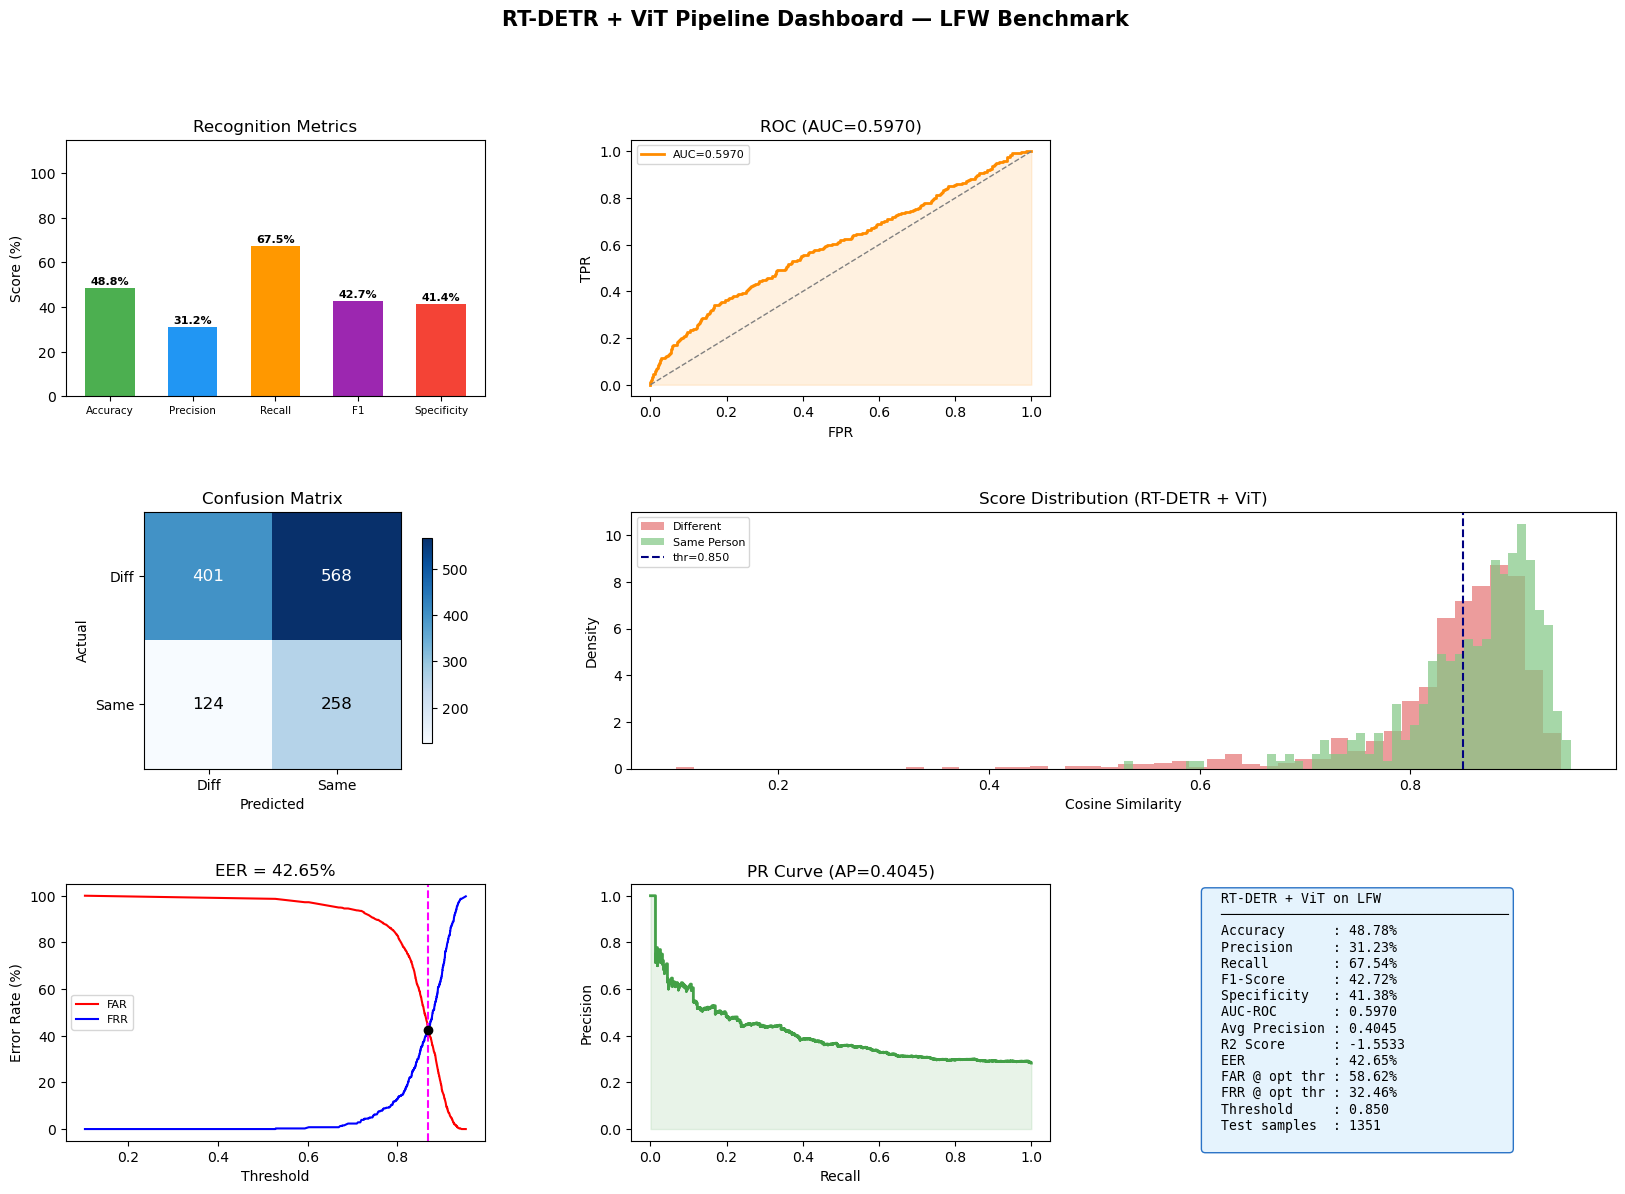

In [13]:
# --- CALCULATE METRICS ---
import matplotlib.gridspec as gridspec
from sklearn.metrics import average_precision_score, precision_recall_curve, r2_score

def compute_eer(y_true, scores):
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    fnr = 1 - tpr
    idx = np.argmin(np.abs(fpr - fnr))
    eer = (fpr[idx] + fnr[idx]) / 2.0
    return eer, thresholds[idx], fpr, tpr, fnr, thresholds

def plot_dashboard(y_true, y_pred, scores, threshold):
    RESULTS_DIR = Path("eval_results")
    RESULTS_DIR.mkdir(exist_ok=True)
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    spec = tn / (tn + fp + 1e-8)

    fpr_r, tpr_r, _ = roc_curve(y_true, scores)
    roc_auc = auc(fpr_r, tpr_r)
    p_pr, r_pr, _   = precision_recall_curve(y_true, scores)
    ap  = average_precision_score(y_true, scores)
    eer, eer_thr, fpr_e, tpr_e, fnr_e, thr_e = compute_eer(y_true, scores)
    r2  = r2_score(y_true, scores)

    fig = plt.figure(figsize=(20, 13))
    fig.suptitle("RT-DETR + ViT Pipeline Dashboard — LFW Benchmark",
                 fontsize=15, fontweight="bold")
    gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

    # 1. Classification metrics
    ax1 = fig.add_subplot(gs[0, 0])
    labels = ["Accuracy", "Precision", "Recall", "F1", "Specificity"]
    vals   = [acc, prec, rec, f1, spec]
    colors = ["#4CAF50", "#2196F3", "#FF9800", "#9C27B0", "#F44336"]
    bars   = ax1.bar(labels, [v*100 for v in vals], color=colors, width=0.6)
    for bar, val in zip(bars, vals):
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f"{val*100:.1f}%", ha="center", va="bottom", fontsize=8, fontweight="bold")
    ax1.set_ylim(0, 115)
    ax1.set_title("Recognition Metrics")
    ax1.set_ylabel("Score (%)")
    ax1.tick_params(axis="x", labelsize=7.5)

    # 3. ROC Curve (taking up the middle/right of top row equivalent in original was 2 for detection, we'll shift)
    ax3 = fig.add_subplot(gs[0, 1])
    ax3.plot(fpr_r, tpr_r, color="#FF8C00", lw=2, label=f"AUC={roc_auc:.4f}")
    ax3.plot([0, 1], [0, 1], "--", color="grey", lw=1)
    ax3.fill_between(fpr_r, tpr_r, alpha=0.12, color="#FF8C00")
    ax3.set_xlabel("FPR"); ax3.set_ylabel("TPR")
    ax3.set_title(f"ROC (AUC={roc_auc:.4f})")
    ax3.legend(fontsize=8)

    # 4. Confusion Matrix
    ax4 = fig.add_subplot(gs[1, 0])
    cm  = np.array([[tn, fp], [fn, tp]])
    im  = ax4.imshow(cm, cmap="Blues")
    ax4.set_xticks([0, 1]); ax4.set_yticks([0, 1])
    ax4.set_xticklabels(["Diff", "Same"]); ax4.set_yticklabels(["Diff", "Same"])
    ax4.set_xlabel("Predicted"); ax4.set_ylabel("Actual")
    ax4.set_title("Confusion Matrix")
    for r in range(2):
        for c in range(2):
            ax4.text(c, r, str(cm[r, c]), ha="center", va="center",
                     fontsize=12, color="white" if cm[r, c] > cm.max()/2 else "black")
    plt.colorbar(im, ax=ax4, shrink=0.8)

    # 5. Score Distribution
    ax5 = fig.add_subplot(gs[1, 1:3])
    y_true_arr = np.array(y_true)
    y_scores_arr = np.array(scores)
    same_s = y_scores_arr[y_true_arr == 1]
    diff_s = y_scores_arr[y_true_arr == 0]
    ax5.hist(diff_s, bins=50, color="#E57373", alpha=0.7, density=True, label="Different")
    ax5.hist(same_s, bins=50, color="#81C784", alpha=0.7, density=True, label="Same Person")
    ax5.axvline(threshold, color="navy", linestyle="--", lw=1.5, label=f"thr={threshold:.3f}")
    ax5.set_xlabel("Cosine Similarity"); ax5.set_ylabel("Density")
    ax5.set_title("Score Distribution (RT-DETR + ViT)")
    ax5.legend(fontsize=8)

    # 6. EER Curve
    ax6 = fig.add_subplot(gs[2, 0])
    ax6.plot(thr_e, fpr_e*100, color="red",  label="FAR")
    ax6.plot(thr_e, fnr_e*100, color="blue", label="FRR")
    ax6.axvline(eer_thr, color="magenta", linestyle="--", lw=1.5)
    ax6.scatter([eer_thr], [eer*100], color="black", zorder=5)
    ax6.set_xlabel("Threshold"); ax6.set_ylabel("Error Rate (%)")
    ax6.set_title(f"EER = {eer*100:.2f}%")
    ax6.legend(fontsize=8)

    # 7. PR Curve
    ax7 = fig.add_subplot(gs[2, 1])
    ax7.step(r_pr, p_pr, color="#43A047", where="post", lw=2)
    ax7.fill_between(r_pr, p_pr, alpha=0.12, color="#43A047")
    ax7.set_xlabel("Recall"); ax7.set_ylabel("Precision")
    ax7.set_title(f"PR Curve (AP={ap:.4f})")

    # 8. Summary Box
    ax8 = fig.add_subplot(gs[2, 2])
    ax8.axis("off")
    far_idx = np.argmin(np.abs(thr_e - threshold))
    summary = (
        f"  RT-DETR + ViT on LFW\n"
        f"  {'─'*36}\n"
        f"  Accuracy      : {acc*100:.2f}%\n"
        f"  Precision     : {prec*100:.2f}%\n"
        f"  Recall        : {rec*100:.2f}%\n"
        f"  F1-Score      : {f1*100:.2f}%\n"
        f"  Specificity   : {spec*100:.2f}%\n"
        f"  AUC-ROC       : {roc_auc:.4f}\n"
        f"  Avg Precision : {ap:.4f}\n"
        f"  R2 Score      : {r2:.4f}\n"
        f"  EER           : {eer*100:.2f}%\n"
        f"  FAR @ opt thr : {fpr_e[far_idx]*100:.2f}%\n"
        f"  FRR @ opt thr : {fnr_e[far_idx]*100:.2f}%\n"
        f"  Threshold     : {threshold:.3f}\n"
        f"  Test samples  : {len(y_true)}\n"
    )
    ax8.text(0.02, 0.97, summary, transform=ax8.transAxes,
             fontsize=9.5, verticalalignment="top", fontfamily="monospace",
             bbox=dict(boxstyle="round", facecolor="#E3F2FD", alpha=0.9, edgecolor="#1565C0"))

    out = RESULTS_DIR / "rtdetr_vit_lfw_dashboard.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    print(f"\n📊 Dashboard saved: {out}")
    plt.show()

if y_true:
    plot_dashboard(y_true, y_pred, y_scores, EVAL_THRESHOLD)
else:
    print("No valid embeddings were extracted from the Test set.")
